# Modelo 2 — Clasificador OCT con segmentación previa

In [15]:
descargar_dataset_completo = False

In [41]:
import os
from pathlib import Path

if descargar_dataset_completo:
    import kagglehub

    # Setea la carpeta data como default para almacenar los datasets descargados
    os.environ["KAGGLEHUB_CACHE"] = "./data"

    # ── Rutas ──────────────────────────────────────────────────────────────
    output_dir = os.path.abspath('./data/datasets/paultimothymooney/kermany2018/versions/2')
    dir_kaggle_clas = 'paultimothymooney/kermany2018'

    if os.access(output_dir, os.F_OK) is False:
        path = kagglehub.dataset_download(dir_kaggle_clas)
        output_dir = os.path.abspath(path)
    else:
        print('El dataset COMPLETO ya ha sido descargado previamente.')

else:

    import gdown
    import zipfile

    output_zip = 'data/oct_sample.zip'
    output_dir = 'data/oct_sample' # Nombre de la carpeta de destino

    if os.access(output_dir, os.F_OK) is False:
        os.makedirs(output_dir, exist_ok=True)
        gdown.download(id='1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF', output=output_zip, quiet=False, fuzzy=True)

        if os.path.exists(output_zip):
            # Descomprimir el archivo
            print(f"Descomprimiendo {output_zip}...")
            with zipfile.ZipFile(output_zip, 'r') as zip_ref:
                zip_ref.extractall(output_dir)

            # Opcional: Eliminar el archivo .zip para ahorrar espacio
            os.remove(output_zip)
            print(f"Archivos extraídos en la carpeta: '{output_dir}'")
        else:
            print("Error: No se pudo encontrar el archivo descargado. Revisa los permisos del link.")
    else:
        print('El dataset MUESTRA ya ha sido descargado previamente.')

Downloading...
From (original): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF
From (redirected): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF&confirm=t&uuid=b10a3e88-6c54-46ae-95c7-69e36bd18f2f
To: /content/data/oct_sample.zip
100%|██████████| 937M/937M [00:10<00:00, 89.0MB/s]


Descomprimiendo data/oct_sample.zip...
Archivos extraídos en la carpeta: 'data/oct_sample'


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
from PIL import Image
import numpy as np


device = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAIN_PATH  =  Path(os.path.join(output_dir,"OCT2017 /train"))
VAL_PATH   = Path(os.path.join(output_dir,"OCT2017 /val"))
TEST_PATH   = Path(os.path.join(output_dir,"OCT2017 /test"))

print(f"Ruta de las imágenes TRAIN: {TRAIN_PATH}")
print(f"Ruta de las imágenes VAL: {VAL_PATH}")
print(f"Ruta de las imágenes TEST: {TEST_PATH}")

Ruta de las imágenes TRAIN: data/oct_sample/OCT2017 /train
Ruta de las imágenes VAL: data/oct_sample/OCT2017 /val
Ruta de las imágenes TEST: data/oct_sample/OCT2017 /test


In [34]:
weights_dir = 'modelos'
weights_path = os.path.join(weights_dir, 'unetpp_smp_finetunning.pth')
if not os.path.exists(weights_path):
    os.makedirs(weights_dir, exist_ok=True)

    import gdown
    gdown.download(id='1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp',
               output=weights_path,
               fuzzy=True)
else:
    print('Pesos del modelo segmentador ya descargados')


!ls -R /content/modelos

print(os.path.exists(weights_path))
print(os.path.getsize(weights_path))

Downloading...
From (original): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp
From (redirected): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp&confirm=t&uuid=b4c5ab2a-bc20-4546-8a5e-cb2d12c0d3c8
To: /content/modelos/unetpp_smp_finetunning.pth
100%|██████████| 105M/105M [00:00<00:00, 156MB/s]


In [19]:
pip install segmentation_models_pytorch

In [35]:
# ── Carga del modelo de segmentación ──────────────────────────────────
# El modelo es UNet++ con encoder ResNet34, 1 canal entrada, 8 clases de salida.
# Guardado con torch.save(model.state_dict(), ...)

import segmentation_models_pytorch as smp

seg_model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights=None,   # no cargar imagenet, vamos a cargar nuestros pesos
    in_channels=1,
    classes=8
)

import os
size = os.path.getsize('modelos/unetpp_smp_finetunning.pth')
print(f"{size / 1024 / 1024:.1f} MB")  # debe decir ~99.6 MB

seg_model.load_state_dict(torch.load(weights_path, map_location=device))
seg_model.to(device)
seg_model.eval()

# Congelar: no queremos que se entrene junto con el clasificador
for param in seg_model.parameters():
    param.requires_grad = False

print('Modelo de segmentación cargado y congelado.')

99.7 MB
Modelo de segmentación cargado y congelado.


In [45]:
# ── Dataset con segmentación on-the-fly ───────────────────────────────
# Pipeline por imagen:
#   1. Cargar imagen OCT (RGB desde ImageFolder)
#   2. Convertir a escala de grises (1 canal) → pasar por seg_model
#   3. La máscara resultante (valores 0-7) se normaliza a [0,1] y se
#      repite en 3 canales para que sea compatible con ResNet50
#   4. Aplicar normalización ImageNet

from torch.utils.data import Subset
class SegmentedDataset(Dataset):
    def __init__(self, folder_path, seg_model, augment=False):
        self.base_ds   = datasets.ImageFolder(folder_path)
        self.seg_model = seg_model
        self.augment   = augment
        self.classes   = self.base_ds.classes

        # Pre-procesado para el modelo de segmentación
        # UNet++ espera (1, H, W) normalizado [0,1]
        self.to_seg = transforms.Compose([
            transforms.Resize((224, 512)),   # mismo tamaño usado en entrenamiento del segmentador
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),           # [0,1]
        ])

        # Post-procesado: la máscara se normaliza y pasa a 3 canales
        self.post = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
        ]) if augment else nn.Identity()

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img_pil, label = self.base_ds.imgs[idx]
        img_pil = Image.open(img_pil).convert('RGB')

        # 1. Preparar input para segmentador (escala de grises, 1 canal)
        x_seg = self.to_seg(img_pil).unsqueeze(0).to(device)  # (1,1,H,W)

        # 2. Inferencia del segmentador → máscara (H,W) con valores 0-7
        with torch.no_grad():
            logits = self.seg_model(x_seg)           # (1,8,H,W)
            mask   = logits.argmax(dim=1).squeeze(0) # (H,W)

        # 3. Normalizar máscara a [0,1] y expandir a 3 canales
        mask_f = mask.float() / 7.0                  # (H,W) en [0,1]
        mask_3c = mask_f.unsqueeze(0).repeat(3,1,1)  # (3,H,W)

        # 4. Augmentación + normalización ImageNet
        mask_3c = self.aug(mask_3c)
        mask_3c = self.post(mask_3c)

        return mask_3c.cpu(), label


train_ds = SegmentedDataset(TRAIN_PATH, seg_model, augment=True)
val_ds   = SegmentedDataset(VAL_PATH,   seg_model, augment=False)
test_ds  = SegmentedDataset(TEST_PATH,  seg_model, augment=False)

indices_train = np.random.choice(len(train_ds), 2000, replace=False)


# num_workers=0 porque el segmentador corre en GPU/CPU principal
train_loader = DataLoader(Subset(train_ds, indices_train), batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f'Train: {len(indices_train)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Clases: {train_ds.classes}')

Train: 2000 | Val: 2032 | Test: 4015
Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [46]:
# ── Modelo clasificador ───────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)   # CNV, DME, DRUSEN, NORMAL
model.to(device)

# ── Loss + optimizer ──────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


In [47]:
# ── Train loop ────────────────────────────────────────────────────────
from tqdm import tqdm

epochs     = 20
patience   = 5
best_val   = float('inf')
bad_epochs = 0

os.makedirs('modelos', exist_ok=True)
best_path = 'modelos/modelo2_seg_resnet50.pth'

for epoch in range(epochs):

    # ── train ──
    model.train()
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'Epoch {epoch+1} train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── val ──
    model.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            val_loss    += loss_fn(logits, y).item()
            val_correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}')

    # ── early stopping ──
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✅ Mejoró val_loss. Guardado en {best_path}')
    else:
        bad_epochs += 1
        print(f'  ⏳ No mejoró. patience: {bad_epochs}/{patience}')

        if bad_epochs >= patience:
            print(f'🛑 Early stopping: {patience} épocas sin mejora.')
            break

print('Entrenamiento finalizado.')

Epoch 1 train: 100%|██████████| 125/125 [01:07<00:00,  1.86it/s]


Epoch 1/20 - train loss: 1.0597 - val loss: 0.9598 - val acc: 0.5906
  ✅ Mejoró val_loss. Guardado en modelos/modelo2_seg_resnet50.pth


Epoch 2 train: 100%|██████████| 125/125 [01:05<00:00,  1.90it/s]


Epoch 2/20 - train loss: 0.7222 - val loss: 0.8574 - val acc: 0.6403
  ✅ Mejoró val_loss. Guardado en modelos/modelo2_seg_resnet50.pth


Epoch 3 train: 100%|██████████| 125/125 [01:05<00:00,  1.90it/s]


...

Epoch 8/20 - train loss: 0.2829 - val loss: 1.1496 - val acc: 0.6348
  ⏳ No mejoró. patience: 3/5


Epoch 9 train: 100%|██████████| 125/125 [01:05<00:00,  1.91it/s]


Epoch 9/20 - train loss: 0.2515 - val loss: 1.2676 - val acc: 0.6526
  ⏳ No mejoró. patience: 4/5


Epoch 10 train: 100%|██████████| 125/125 [01:05<00:00,  1.91it/s]


Epoch 10/20 - train loss: 0.2153 - val loss: 0.9381 - val acc: 0.6969
  ⏳ No mejoró. patience: 5/5
🛑 Early stopping: 5 épocas sin mejora.
Entrenamiento finalizado.


              precision    recall  f1-score   support

         CNV       0.84      0.77      0.81       990
         DME       0.70      0.83      0.76      1002
      DRUSEN       0.62      0.55      0.59      1021
      NORMAL       0.65      0.67      0.66      1002

    accuracy                           0.70      4015
   macro avg       0.71      0.71      0.70      4015
weighted avg       0.71      0.70      0.70      4015



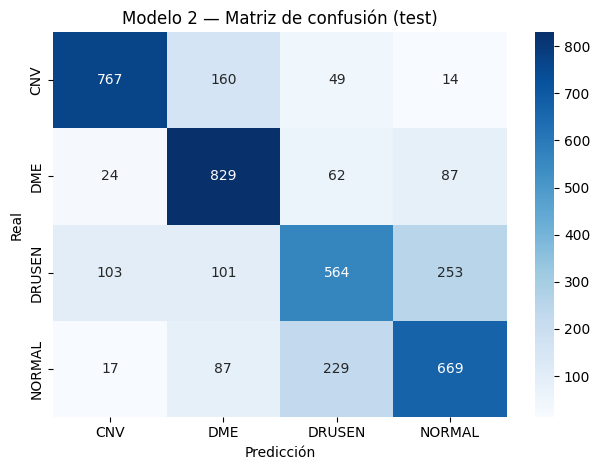

In [48]:
# ── Evaluación en test ────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Modelo 2 — Matriz de confusión (test)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()